#Importing the Dependencies

In [59]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Lasso
from sklearn import metrics

#Data Collection and Processing

In [60]:
# loading the data from csv file to pandas dataframe
car_dataset = pd.read_csv("C:\\Users\\siddh\\OneDrive\\Desktop\\ai ml poject\\dataset.csv")

In [61]:
# inspecting the first 5 rows of the dataframe
car_dataset.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,5
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,5
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,5
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,5
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,5


In [62]:
# checking the number of rows and columns
car_dataset.shape

(8128, 8)

In [63]:
# getting some information about the dataset
car_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8128 entries, 0 to 8127
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   name           8128 non-null   object
 1   year           8128 non-null   int64 
 2   selling_price  8128 non-null   int64 
 3   km_driven      8128 non-null   int64 
 4   fuel           8128 non-null   object
 5   seller_type    8128 non-null   object
 6   transmission   8128 non-null   object
 7   seats          8128 non-null   int64 
dtypes: int64(4), object(4)
memory usage: 508.1+ KB


In [64]:
# checking the number of missing values
car_dataset.isnull().sum()

name             0
year             0
selling_price    0
km_driven        0
fuel             0
seller_type      0
transmission     0
seats            0
dtype: int64

In [65]:
# checking the distribution of categorical data
print(car_dataset.fuel.value_counts())
print(car_dataset.seller_type.value_counts())
print(car_dataset.transmission.value_counts())

fuel
Diesel    4402
Petrol    3631
CNG         57
LPG         38
Name: count, dtype: int64
seller_type
Individual          6766
Dealer              1126
Trustmark Dealer     236
Name: count, dtype: int64
transmission
Manual       7078
Automatic    1050
Name: count, dtype: int64


#Encoding the Categorical Data

In [66]:
# encoding the categorical data
pd.set_option("future.no_silent_downcasting", True)
car_dataset.replace({"fuel": {"Petrol": 0, "Diesel": 1, "CNG": 2,"LPG": 3}}, inplace=True)
car_dataset.replace({"seller_type": {"Dealer": 0, "Individual": 1,"Trustmark Dealer": 2}}, inplace=True)
car_dataset.replace({"transmission": {"Manual": 0, "Automatic": 1}}, inplace=True)


In [67]:
car_dataset.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,1,1,0,5
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,1,1,0,5
2,Honda City 2017-2020 EXi,2006,158000,140000,0,1,0,5
3,Hyundai i20 Sportz Diesel,2010,225000,127000,1,1,0,5
4,Maruti Swift VXI BSIII,2007,130000,120000,0,1,0,5


#Splitting the data and Target

In [68]:
X = car_dataset.drop(['name','selling_price'],axis=1)
Y = car_dataset['selling_price']

In [69]:
print(X)

      year  km_driven fuel seller_type transmission  seats
0     2014     145500    1           1            0      5
1     2014     120000    1           1            0      5
2     2006     140000    0           1            0      5
3     2010     127000    1           1            0      5
4     2007     120000    0           1            0      5
...    ...        ...  ...         ...          ...    ...
8123  2013     110000    0           1            0      5
8124  2007     119000    1           1            0      5
8125  2009     120000    1           1            0      5
8126  2013      25000    1           1            0      5
8127  2013      25000    1           1            0      5

[8128 rows x 6 columns]


In [70]:
print(Y)

0       450000
1       370000
2       158000
3       225000
4       130000
         ...  
8123    320000
8124    135000
8125    382000
8126    290000
8127    290000
Name: selling_price, Length: 8128, dtype: int64


Splitting Training and Test data

In [71]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.2, random_state=2)

Model Training

#1. Linear Regression

In [72]:
# loading the linear regression model
lin_reg_model = LinearRegression()

In [73]:
lin_reg_model.fit(X_train,Y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


#Model Evaluation

In [74]:
# prediction on Training data
training_data_prediction = lin_reg_model.predict(X_train)

In [75]:
# R squared Error
error_score = metrics.r2_score(Y_train, training_data_prediction)
print("R squared Error : ", error_score)

R squared Error :  0.48556841704407183


#Visualize the actual prices and Predicted prices

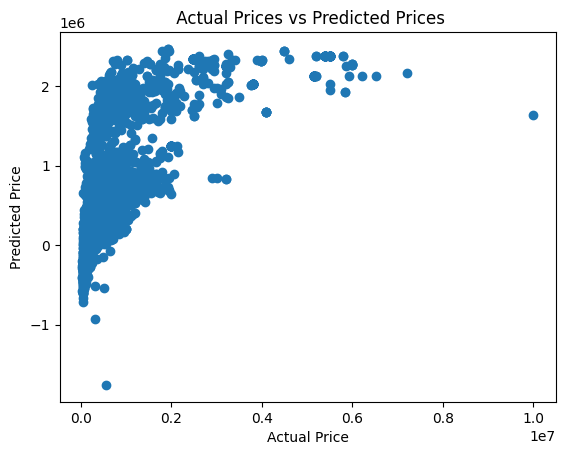

In [76]:
plt.scatter(Y_train, training_data_prediction)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title(" Actual Prices vs Predicted Prices")
plt.show()

In [77]:
# prediction on Training data
test_data_prediction = lin_reg_model.predict(X_test)

In [78]:
# R squared Error
error_score = metrics.r2_score(Y_test, test_data_prediction)
print("R squared Error : ", error_score)

R squared Error :  0.49924336606597086


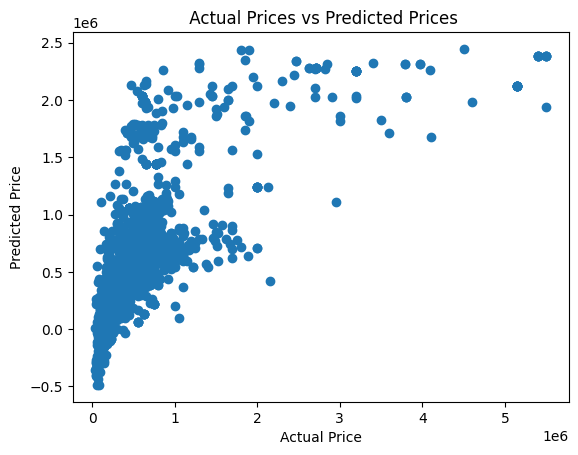

In [79]:
plt.scatter(Y_test, test_data_prediction)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title(" Actual Prices vs Predicted Prices")
plt.show()

#2. Lasso Regression

In [80]:
# loading the linear regression model
lass_reg_model = Lasso()

In [81]:
lass_reg_model.fit(X_train,Y_train)

,"alpha alpha: float, default=1.0Constant that multiplies the L1 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Lasso` object is not advised.Instead, you should use the :class:`LinearRegression` object.",1.0
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"precompute precompute: bool or array-like of shape (n_features, n_features), default=FalseWhether to use a precomputed Gram matrix to speed upcalculations. The Gram matrix can also be passed as argument.For sparse input this option is always ``False`` to preserve sparsity.",False
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=1000The maximum number of iterations.",1000
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``, see Notes below.",0.0001
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fit asinitialization, otherwise, just erase the previous solution.See :term:`the Glossary `.",False
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.",False
,"random_state random_state: int, RandomState instance, default=NoneThe seed of the pseudo random number generator that selects a randomfeature to update. Used when ``selection`` == 'random'.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",None
,"selection selection: {'cyclic', 'random'}, default='cyclic'If set to 'random', a random coefficient is updated every iterationrather than looping over features sequentially by default. This(setting to 'random') often leads to significantly faster convergenceespecially when tol is higher than 1e-4.",'cyclic'


Model Evaluation

In [82]:
# prediction on Training data
training_data_prediction = lass_reg_model.predict(X_train)

In [83]:
# R squared Error
error_score = metrics.r2_score(Y_train, training_data_prediction)
print("R squared Error : ", error_score)

R squared Error :  0.4855684170190888


#Visualize the actual prices and Predicted prices

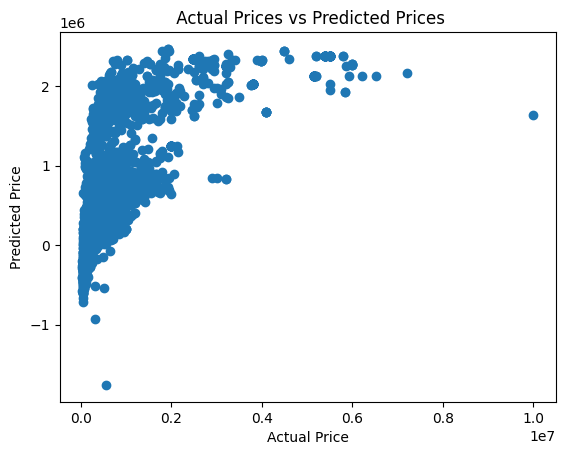

In [84]:
plt.scatter(Y_train, training_data_prediction)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title(" Actual Prices vs Predicted Prices")
plt.show()

In [85]:
# prediction on Training data
test_data_prediction = lass_reg_model.predict(X_test)

In [86]:
# R squared Error
error_score = metrics.r2_score(Y_test, test_data_prediction)
print("R squared Error : ", error_score)

R squared Error :  0.49924355564150347


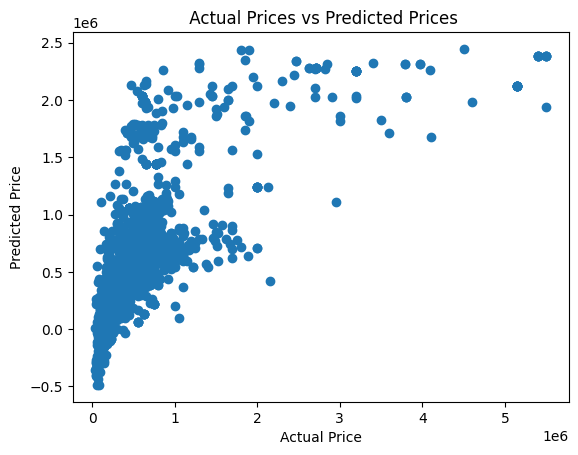

In [87]:
plt.scatter(Y_test, test_data_prediction)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title(" Actual Prices vs Predicted Prices")
plt.show()